* **Problema del negocio:** Los precios de vuelos de avión varían mucho, ya que dependen de muchos factores, como destino, aerolínea, temporada de viaje, la clase, etc.
* **Solución:** Implementación de un modelo predictivo capaz de estimar el precio de boletos de avión utilizando distintas variables.
* **Metodología:** Se utilizará la data de los archivos 'business.xlsx' y 'economy.xlsx', estableciendo la columna price como variable objetivo.
* Se realizará un estudio de la calidad de datos de los archivos, revisando datos nulos, duplicados, outliers, transformación de columnas, etc.
* Al parecer cada archivo tiene las mismas variables, pero se diferencian en el precio: business tiene precios más elevados que economy. Por lo que un análisis de outliers dejaría fuera muchos datos, debido al orden de magnitud que tiene la data.
* Debido a esto, haré cada paso bien detalladamente sólo para uno de los archivos. Luego, crearé una función que automatice todo el trabajo y devuelva un dataset limpio al entregarle un dataframe y lo aplico al segundo archivo.
* Una vez los datos de cada archivo estén limpios, agrego una columna extra a cada dataframe indicando la clase a la que corresponden los datos, para posteriormente unir ambos archivos en un único dataframe.
* Haré un análisis exploratorio de los datos, mostrando gráficas que ayuden a visualizar el comportamiento de los datos y observando la correlación existente entre las variables para cada archivo. 
* Indicaré qué columnas se utilizarán para la predicción de la variable objetivo.
* Luego se entrenarán varios modelos para predecir el precio, dividiendo los datos en entrenamiento y prueba, realizando una búsqueda de hiperparámetros, y finalmente evaluándolos según distintas métricas para establecer el mejor modelo para este problema.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
def outliers(df, columnas, multiplicador = 1.5):
    outliers = {}
    
    # Crea una máscara del mismo largo que el dataframe con valores False.
    mascara = pd.Series(False, index = df.index)
    for col in columnas:
        # Obtengo los outliers superiores e inferiores.
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplicador * IQR
        upper_bound = Q3 + multiplicador * IQR
            
        # Identifico las filas que son outliers para esta columna. Toma como valor True si la fila contiene al menos un valor outlier tanto superior como inferior.
        columna_outlier = (df[col] < lower_bound) | (df[col] > upper_bound)

        # Combino la máscara con la fila que contiene al menos un outlier.
        mascara = mascara | columna_outlier
    
    total_filas_outliers = mascara.sum()
    print(f"Total de filas outliers: {total_filas_outliers}")
    print(f"Porcentaje de filas con outliers: {(total_filas_outliers/len(df))*100:.2f}%")
    
    # Retorno el dataframe sin las filas que contienen al menos un outlier.
    return df[~mascara]

In [3]:
df1_raw = pd.read_excel('business.xlsx')
df2_raw = pd.read_excel('economy.xlsx')

df1 = df1_raw.copy()
df2 = df2_raw.copy()

In [4]:
df1.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690


In [5]:
df1.dtypes

date          datetime64[ns]
airline               object
ch_code               object
num_code               int64
dep_time              object
from                  object
time_taken            object
stop                  object
arr_time              object
to                    object
price                 object
dtype: object

In [6]:
# Checkeo valores nulos.
df1.isna().sum().sum()

0

Veo que columnas que uno esperaría que fueran de tipo datetime o numéricas son de tipo object. Primero, intento convertir la columna price a tipo numérico. 

Para ello, utilizo pd.to_numeric() y usaré errors = 'coerce', esto convertirá aquellos valores que no se pueden transformar a tipo numérico como nan.

In [7]:
# Creo un dataframe convertido a numérico, donde aquellos valores que no eran válidos quedan como nan.
converted = pd.to_numeric(df1['price'], errors = 'coerce')

# Creo un dataframe con aquellas filas que contienen nan del dataframe anterior.
bad_rows = df1[converted.isna()]

# Visualizo los valores del dataframe original no convertido a numérico que no podían sen transformados
bad_rows['price'].unique()

array(['1,14,434', '1,16,562', '1,00,395', '1,01,369', '1,17,307',
       '1,05,961', '1,02,114', '1,10,850', '1,10,872', '1,14,507',
       '1,04,987', '1,04,466', '1,00,288', '1,00,473', '1,03,335',
       '1,11,437', '1,01,531', '1,02,404', '1,05,764', '1,11,163',
       '1,14,523', '1,00,276', '1,01,844', '1,00,909', '1,08,604',
       '1,11,964', '1,06,476', '1,00,204', '1,11,883', '1,03,819',
       '1,01,920', '1,05,168', '1,07,576', '1,00,111', '1,00,671',
       '1,01,780', '1,04,031', '1,07,492', '1,23,071', '1,02,648',
       '1,08,360', '1,09,217', '1,10,936', '1,04,255', '1,07,934',
       '1,05,549', '1,05,638', '1,06,753', '1,01,612', '1,05,185',
       '1,10,225', '1,14,705', '1,00,539', '1,15,211', '1,03,683',
       '1,01,376', '1,10,218', '1,01,152', '1,01,824', '1,03,056',
       '1,05,744', '1,09,776', '1,14,704', '1,07,216', '1,06,416',
       '1,07,597', '1,02,832', '1,02,384', '1,04,624'], dtype=object)

El problema radica en que la columna price contiene valores en que el separador de coma está mal formateado, por lo que ahora sé que tengo que remover las comas para obtener sólo los números.

In [8]:
# Elimino las comas de la columna.
df1['price'] = df1['price'].astype(str).str.replace(',', '', regex = False)

In [9]:
# Establezco la columna price como numérico.
df1['price'] = pd.to_numeric(df1['price'], errors = 'raise')

In [10]:
df1.dtypes

date          datetime64[ns]
airline               object
ch_code               object
num_code               int64
dep_time              object
from                  object
time_taken            object
stop                  object
arr_time              object
to                    object
price                  int64
dtype: object

Ahora sí se transformó correctamente la columna a tipo numérico.

La columna ch_code es una abreviación del nombre de la aerolínea, por lo que concatenaré ésta columna con num_code para obtener una ID única para cada vuelo.

In [11]:
df1['ID'] = df1['ch_code'].astype(str) + ' ' + df1['num_code'].astype(str)

In [12]:
# Elimino las columnas ch_code y num_code ya que son redundantes con la nueva columna ID.
df1 = df1.drop(columns = ['ch_code', 'num_code'])

Las columnas dep_time y arr_time son de tipo object cuando quizá se quiera usar el formato datetime. Lo que haré es crear una columna, que será la concatenación de la columna date con dep_time para obtener la fecha completa de salida. Luego, convertiré la columna time_taken en datetime para poder sumarlo a la nueva columna full_dep_time para obtener la fecha completa de llegada full_arr_time.

In [13]:
# Agrego la nueva columna con la fecha completa.
df1['full_dep_time'] = df1['date'].astype(str) + ' ' + df1['dep_time'].astype(str)

# Convierto la nueva columna a formato datetime.
df1['full_dep_time'] = pd.to_datetime(df1['full_dep_time'], errors = 'raise')

In [14]:
# Convierto la columna time_taken que contiene texto en timedelta para poder realizar operaciones.
def texto_a_tiempo(texto):
    # Busca aquellos números que están seguidos por h. Son las horas.
    horas = re.search(r'(\d+)h', texto)
    
    # Aquellos números que están seguidos de m son los minutos.
    mins = re.search(r'(\d+)m', texto)

    # Si no se encuentran horas o minutos devuelve un cero.
    h = int(horas.group(1)) if horas else 0
    m = int(mins.group(1)) if mins else 0

    # Transforma los números a tipo timedelta.
    return pd.Timedelta(hours = h, minutes = m)

df1['time_taken'] = df1['time_taken'].apply(texto_a_tiempo)

# Calculo la fecha de llegada.
df1['full_arr_time'] = df1['full_dep_time'] + df1['time_taken']

In [15]:
# Convierto la columna time_taken a float.
df1['time_taken'] = df1['time_taken'].dt.total_seconds() / 3600

In [16]:
# Elimino las columnas que son redundantes.
df1 = df1.drop(columns = ['date', 'dep_time', 'arr_time'])

In [17]:
df1.head()

,airline,from,time_taken,stop,to,price,ID,full_dep_time,full_arr_time
0,Air India,Delhi,2.000000,non-stop,Mumbai,25612,AI 868,2022-02-11 18:00:00,2022-02-11 20:00:00
1,Air India,Delhi,2.250000,non-stop,Mumbai,25612,AI 624,2022-02-11 19:00:00,2022-02-11 21:15:00
2,Air India,Delhi,24.750000,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Mumbai,42220,AI 531,2022-02-11 20:00:00,2022-02-12 20:45:00
3,Air India,Delhi,26.500000,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Mumbai,44450,AI 839,2022-02-11 21:25:00,2022-02-12 23:55:00
4,Air India,Delhi,6.666667,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Mumbai,46690,AI 544,2022-02-11 17:15:00,2022-02-11 23:55:00


La columna stop contiene texto, pero aparecen los caracteres de nueva línea \n y de tabulación \t de manera literal, a pesar de que representan espacio blanco, por lo que limpiaré estos caracteres para tener los valores de manera más legible.

In [18]:
# Reemplazo cualquier espacio que se considera blanco como espacios, saltos de línea, tabulaciones (\s+) con un único espacio.
df1['stop'] = df1['stop'].str.replace(r'\s+', ' ', regex = True).str.strip()

In [19]:
df1['stop'].value_counts()

stop
1-stop                    81489
non-stop                   8102
2+-stop                    1083
1-stop Via IDR              810
1-stop Via IXU              776
1-stop Via PAT              257
1-stop Via Patna            242
1-stop Via BBI              152
1-stop Via STV               93
1-stop Via IXE               86
1-stop Via Bhubaneswar       75
1-stop Via Hyderabad         71
1-stop Via Delhi             59
1-stop Via Raipur            43
1-stop Via Chennai           42
1-stop Via Guwahati          29
1-stop Via VTZ               17
1-stop Via NDC               14
1-stop Via Kolkata           14
1-stop Via RPR               13
1-stop Via Lucknow           10
1-stop Via GAU                3
1-stop Via GAY                3
1-stop Via Surat              3
1-stop Via HYD                1
Name: count, dtype: int64

Hay claramente 3 grupos: sin paradas, 1 parada o dos paradas. Aquellos con 1 parada se pueden diferenciar entre ellos, esos datos son pocos en comparación con el total, por los que los juntaré todos bajo una misma categoría de 1 parada para simplificar.

In [20]:
# Primero creo una columna en la que por defecto es 1 parada. Luego, uso .str.contains() para reemplazar los valores a 0 cuando es non-stop 
# o 2 cuando es 2+-stop.
df1['num_stops'] = 1
df1.loc[df1['stop'].str.contains('non-stop'), 'num_stops'] = 0
df1.loc[df1['stop'].str.contains(r'2\+-stop'), 'num_stops'] = 2

print(df1['num_stops'].value_counts())

num_stops
1    84302
0     8102
2     1083
Name: count, dtype: int64


In [21]:
df1[['stop', 'num_stops']].value_counts()

stop                    num_stops
1-stop                  1            81489
non-stop                0             8102
2+-stop                 2             1083
1-stop Via IDR          1              810
1-stop Via IXU          1              776
1-stop Via PAT          1              257
1-stop Via Patna        1              242
1-stop Via BBI          1              152
1-stop Via STV          1               93
1-stop Via IXE          1               86
1-stop Via Bhubaneswar  1               75
1-stop Via Hyderabad    1               71
1-stop Via Delhi        1               59
1-stop Via Raipur       1               43
1-stop Via Chennai      1               42
1-stop Via Guwahati     1               29
1-stop Via VTZ          1               17
1-stop Via NDC          1               14
1-stop Via Kolkata      1               14
1-stop Via RPR          1               13
1-stop Via Lucknow      1               10
1-stop Via GAY          1                3
1-stop Via GAU      

El mapeo se aplicó correctamente, ahora voy a eliminar la columna stop y sólo consideraré num_stops.

In [22]:
df1 = df1.drop(columns = 'stop')

Finalmente, agrego una nueva columna que define la clase a la que pertenecen los datos, en este caso, business.

In [23]:
df1['class'] = 'business'

In [24]:
df1.head()

,airline,from,time_taken,to,price,ID,full_dep_time,full_arr_time,num_stops,class
0,Air India,Delhi,2.000000,Mumbai,25612,AI 868,2022-02-11 18:00:00,2022-02-11 20:00:00,0,business
1,Air India,Delhi,2.250000,Mumbai,25612,AI 624,2022-02-11 19:00:00,2022-02-11 21:15:00,0,business
2,Air India,Delhi,24.750000,Mumbai,42220,AI 531,2022-02-11 20:00:00,2022-02-12 20:45:00,1,business
3,Air India,Delhi,26.500000,Mumbai,44450,AI 839,2022-02-11 21:25:00,2022-02-12 23:55:00,1,business
4,Air India,Delhi,6.666667,Mumbai,46690,AI 544,2022-02-11 17:15:00,2022-02-11 23:55:00,1,business


In [25]:
# Checkeo valores duplicados y los elimino si los hubiera.
duplicados = df1.duplicated().sum()
eliminados = len(df1) - len(df1.drop_duplicates())
df1 = df1.drop_duplicates()
print(f'Cantidad de filas duplicadas eliminadas: {eliminados}')

Cantidad de filas duplicadas eliminadas: 0


Ahora checkeo los datos atípicos utilizando el método IQR.

In [26]:
df1 = outliers(df1, ['time_taken', 'price'])

Total de filas outliers: 3745
Porcentaje de filas con outliers: 4.01%


In [27]:
df1.head()

,airline,from,time_taken,to,price,ID,full_dep_time,full_arr_time,num_stops,class
0,Air India,Delhi,2.000000,Mumbai,25612,AI 868,2022-02-11 18:00:00,2022-02-11 20:00:00,0,business
1,Air India,Delhi,2.250000,Mumbai,25612,AI 624,2022-02-11 19:00:00,2022-02-11 21:15:00,0,business
2,Air India,Delhi,24.750000,Mumbai,42220,AI 531,2022-02-11 20:00:00,2022-02-12 20:45:00,1,business
3,Air India,Delhi,26.500000,Mumbai,44450,AI 839,2022-02-11 21:25:00,2022-02-12 23:55:00,1,business
4,Air India,Delhi,6.666667,Mumbai,46690,AI 544,2022-02-11 17:15:00,2022-02-11 23:55:00,1,business


Con esto termina la limpieza de datos. Ahora creo una función que tome un dataframe, como el segundo archivo economy, y devuelva un dataframe limpio.

In [28]:
def limpieza_datos(df, clase):
    # Elimino los valores nulos.
    nulos = df.isna().sum().sum()
    num_filas = len(df)
    df = df.dropna().copy()
    num_filas_eliminadas = num_filas - len(df)
    print(f'Cantidad de valores nulos: {nulos}')
    print(f'Cantidad de filas eliminadas que contienen valores nulos: {num_filas_eliminadas}')
    
    # Transformo la columna price a tipo numérico.
    df['price'] = df['price'].astype(str).str.replace(',', '', regex = False)
    df['price'] = pd.to_numeric(df['price'], errors = 'raise')
    
    # Creo una columna con la ID completa del vuelo, concatenando la columna ch_code con num_code.
    df['ID'] = df['ch_code'].astype(str) + ' ' + df['num_code'].astype(str)
    
    # Concateno la columna date con dep_time para obtener la fecha completa de salida.
    df['full_dep_time'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['dep_time'].astype(str))
    
    # Transformo la columna time_taken a tipo timedelta. Luego, creo una columna con la fecha completa de llegada.
    df['time_taken'] = df['time_taken'].apply(texto_a_tiempo)
    df['full_arr_time'] = df['full_dep_time'] + df['time_taken']
    df['time_taken'] = df['time_taken'].dt.total_seconds() / 3600
    
    # Limpio la columna stop y asigno los valores a uno de tres categorías según la cantidad de paradas.
    df['stop'] = df['stop'].str.replace(r'\s+', ' ', regex = True).str.strip()
    df['num_stops'] = 1
    df.loc[df['stop'].str.contains('non-stop'), 'num_stops'] = 0
    df.loc[df['stop'].str.contains(r'2\+-stop'), 'num_stops'] = 2
    
    # Agrego la etiqueta de clase y elimino las columnas ya procesadas.
    df['class'] = clase
    df = df.drop(columns = ['date', 'ch_code', 'num_code', 'dep_time', 'arr_time', 'stop'])

    # Elimino los duplicados.
    duplicados = df.duplicated().sum()
    eliminados = len(df) - len(df.drop_duplicates())
    df = df.drop_duplicates()
    print(f'Cantidad de filas duplicadas eliminadas: {eliminados}')
    
    # Limpio los outliers.
    df_limpio = outliers(df, ['time_taken', 'price'])
    
    return df_limpio

Ahora creo un for loop para aplicar la función a los dataframes que tuviere, de manera que funcione no sólo para los dos archivos que tenemos, sino para todos los que tuviera.

In [29]:
# Creo una 'lista' de dataframes con su respectivo nombre.
dataframes = [(df1_raw, 'business'), (df2_raw, 'economy')]

# Lista vacía para ir guardando los dataframes ya limpios.
df_limpios = []

# Loop que aplica la función hecha anteriormente para limpiar y procesar los dataframes.
for df, nombre in dataframes:
    print(f'Limpiando dataframe {nombre}:\n')
    df_transf = limpieza_datos(df, nombre)
    df_limpios.append(df_transf)
    print('\n')

df = pd.concat(df_limpios, ignore_index = True)

Limpiando dataframe business:

Cantidad de valores nulos: 0
Cantidad de filas eliminadas que contienen valores nulos: 0
Cantidad de filas duplicadas eliminadas: 0
Total de filas outliers: 3745
Porcentaje de filas con outliers: 4.01%


Limpiando dataframe economy:

Cantidad de valores nulos: 0
Cantidad de filas eliminadas que contienen valores nulos: 0
Cantidad de filas duplicadas eliminadas: 2
Total de filas outliers: 15558
Porcentaje de filas con outliers: 7.52%




In [30]:
df[['time_taken', 'full_dep_time', 'full_arr_time']].describe()

,time_taken,full_dep_time,full_arr_time
count,280956.000000,280956,280956
mean,12.017736,2022-03-09 10:28:20.588348160,2022-03-09 22:29:24.438559744
min,0.833333,2022-02-11 03:00:00,2022-02-11 05:10:00
25%,6.750000,2022-02-26 13:25:00,2022-02-26 23:05:00
50%,11.166667,2022-03-09 16:20:00,2022-03-10 02:10:00
75%,16.000000,2022-03-20 18:00:00,2022-03-21 08:50:00
max,31.250000,2022-03-31 23:55:00,2022-04-01 23:40:00
std,6.931817,NaN,NaN


Los datos de vuelos que se tiene corresponde entre los meses de febrero y marzo.

Comienzo con el análisis exploratorio.

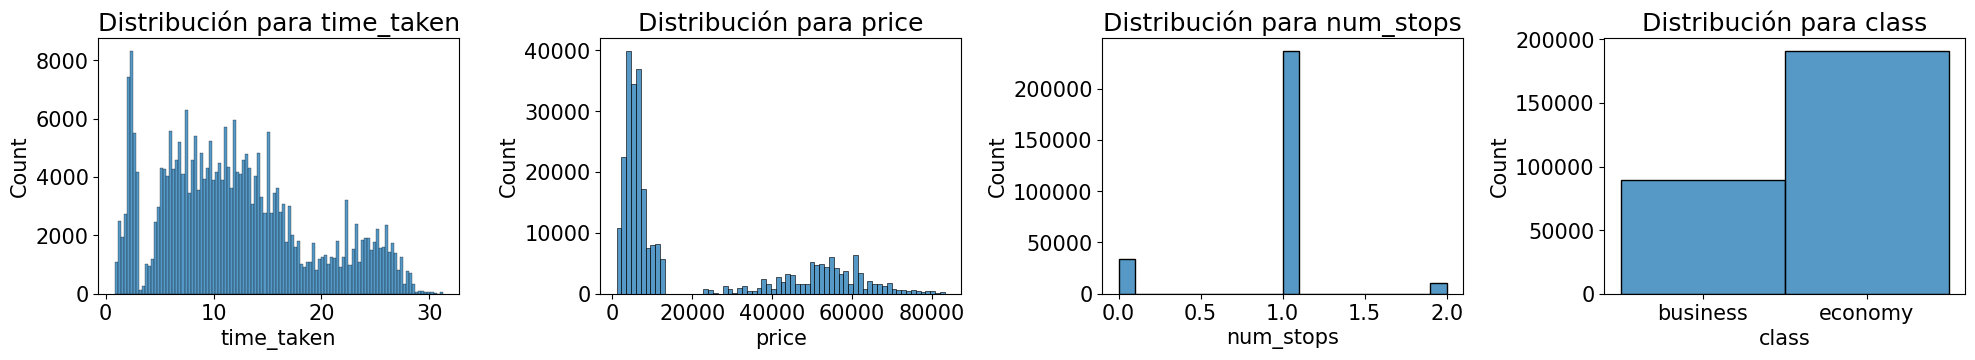

In [31]:
# Grafico la curva de distribución de las columnas del dataframe. 
plt.rcParams.update({'font.size': 15})
plt.figure(figsize = (20, 20))

# Selecciono las columnas que graficaré.
columnas= ['time_taken', 'price', 'num_stops', 'class']
for n, i in enumerate(list(columnas)):
    plt.subplot(6, 4, n + 1)
    
    # Si la columna es de tipo object, grafico la frecuencia que aparece cada valor.
    if df.dtypes.to_list() == 'object':
        sns.countplot(y = df[i], order = df[i].value_counts().iloc[:7].index)
        plt.title('Frecuencias para {}'.format(i))
        
    # Si es de tipo numérico, obtengo la distribución.
    else:
        sns.histplot(df[i])
        plt.title('Distribución para {}'.format(i))
    plt.tight_layout()

* El promedio de las horas de duración de viaje de los datos es de 12 horas.
* En la gráfica de la distribución de la columna price se puede ver claramente los dos grupos de los datasets, uno corresponde al economy y el otro al business. Se puede apreciar que cada uno de estos grupos sigue una distribución normal, en la que la mayor parte de la población compra boletos a un precio cercano al promedio respecto a su clase. Además, existe una mayor frecuencia de boletos de precios bajos.
* La mayoría de los vuelos realizan al menos una parada.
* En nuestro dataframe, se cuenta con un mayor número de datos para la clase economy, casi el doble.

Transformo las columnas categóricas en dummies utilizando one-hot encoding para el posterior uso en los modelos predictivos.

In [32]:
# Selecciono las columnas que transformaré.
transf_columnas = ['airline', 'from', 'to', 'class']

# Creo las columnas dummies.
df = pd.get_dummies(df, columns = transf_columnas, drop_first = True)

In [33]:
df.head()

,time_taken,price,ID,full_dep_time,full_arr_time,num_stops,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,...,from_Delhi,from_Hyderabad,from_Kolkata,from_Mumbai,to_Chennai,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai,class_economy
0,2.000000,25612,AI 868,2022-02-11 18:00:00,2022-02-11 20:00:00,0,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
1,2.250000,25612,AI 624,2022-02-11 19:00:00,2022-02-11 21:15:00,0,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,24.750000,42220,AI 531,2022-02-11 20:00:00,2022-02-12 20:45:00,1,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
3,26.500000,44450,AI 839,2022-02-11 21:25:00,2022-02-12 23:55:00,1,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,6.666667,46690,AI 544,2022-02-11 17:15:00,2022-02-11 23:55:00,1,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


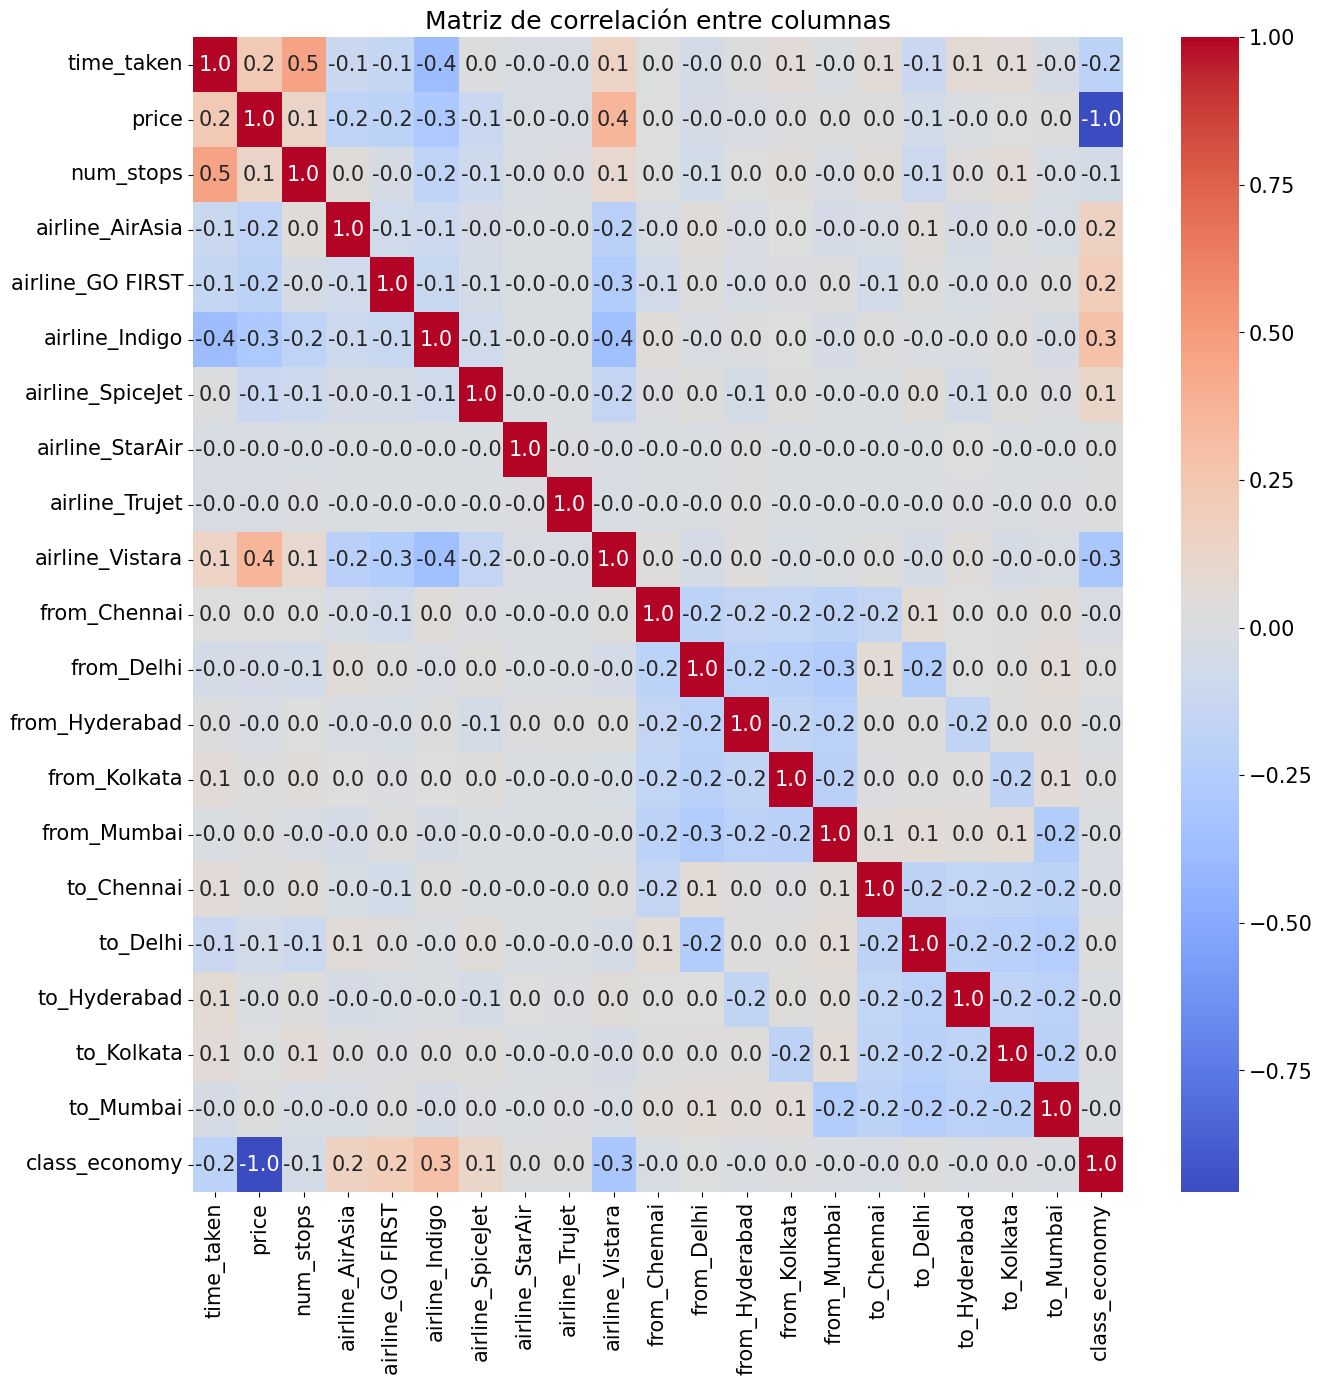

In [34]:
# Correlación entre las columnas.
matriz_correlacion = df.corr(numeric_only = True)

# Creo el mapa de calor.
plt.figure(figsize = (15, 15))
sns.heatmap(matriz_correlacion, annot = True, fmt = '.1f', cmap = 'coolwarm')
plt.title('Matriz de correlación entre columnas')
plt.show()

In [35]:
# Ordeno las correlaciones con respecto a la columna precio.
print(matriz_correlacion['price'].sort_values(ascending = False))

price               1.000000
airline_Vistara     0.365532
time_taken          0.233283
num_stops           0.132459
to_Chennai          0.022789
to_Kolkata          0.021431
from_Chennai        0.020456
from_Kolkata        0.012901
from_Mumbai         0.012749
to_Mumbai           0.009463
to_Hyderabad       -0.007892
airline_Trujet     -0.009282
airline_StarAir    -0.010287
from_Hyderabad     -0.011649
from_Delhi         -0.044525
to_Delhi           -0.055129
airline_SpiceJet   -0.117450
airline_AirAsia    -0.181273
airline_GO FIRST   -0.199546
airline_Indigo     -0.289921
class_economy      -0.955991
Name: price, dtype: float64


* Como se puede observar, existe una muy estrecha correlación (-0.95) entre las columnas precio y class_economy. El valor es negativo, lo que implica que la correlación es inversamente proporcional, es decir, si un valor sube, el otro baja. Este caso tiene todo el sentido, ya que ser de una clase económica implica que el precio es bajo.
* Además, hay una alta correlación entre las aerolíneas Vistara e Indigo con el precio. La correlación de Vistara es positiva, lo que quiere decir que el precio de esta aerolínea tiende a ser mayor, mientras que como la correlación de Indigo es negativa, esta aerolínea puede ser considera low cost.
* Observando la gráfica de la matriz de correlación, se verifica que el número de paradas tiene una alta correlación con el tiempo que tarda el viaje. Además, existe una correlación negativa entre el tiempo que tarda el viaje e Indigo, lo que indica que ésta aerolínea tienden a tener tiempos de viaje más cortos.
* Finalmente, es notable que tanto la ciudad de origen, como el destino, tienen una muy baja correlación con el precio, lo que sugiere que el precio no depende de las ciudades de origen ni destino.

Ahora realizo una selección de variables según los métodos de Forward Selection.

Primero, para que el Forward selection sea más robusto, extraeré la hora de salida y llegada, para ver si esta información impacta más en el precio.

In [36]:
# Creo una copia del dataframe limpio para usarlo en el modelo de Forward Selection.
df_fs = df.copy()

# Extraigo la hora de salida y llegada como números.
df_fs['dep_hour'] = df_fs['full_dep_time'].dt.hour
df_fs['arr_hour'] = df_fs['full_arr_time'].dt.hour

# Defino las características y el target para usar Forward Selection.
X = df_fs.drop(columns = ['ID', 'price', 'full_dep_time', 'full_arr_time'])
y = df_fs['price']

# Uso una regresión lineal, ya que la columna del precio es un número continuo.
base_model = LinearRegression()

# Aplico el forward selection para obtener las variables.
sfs = SequentialFeatureSelector(base_model, n_features_to_select = 10, direction = 'forward', scoring = 'r2', cv = 5, n_jobs = -1)

# Ajusto el modelo.
sfs.fit(X, y)

# Obtengo las variables.
selected_features = X.columns[sfs.support_]
selected_features_ordered = df_fs[selected_features.tolist() + ['price']].corr()['price'].sort_values(ascending = False)
print("Características seleccionadas por Forward Selection ordenadas por importancia según su correlación con price:\n")
print(selected_features_ordered)

Características seleccionadas por Forward Selection ordenadas por importancia según su correlación con price:

price               1.000000
time_taken          0.233283
dep_hour            0.029689
to_Chennai          0.022789
airline_Trujet     -0.009282
airline_StarAir    -0.010287
airline_SpiceJet   -0.117450
airline_AirAsia    -0.181273
airline_GO FIRST   -0.199546
airline_Indigo     -0.289921
class_economy      -0.955991
Name: price, dtype: float64


Según el modelo de Forward Selection, la clase Economy, que sea de la aerolínea Indigo y el tiempo de viaje son las variables más importantes para explicar el precio de los boletos.

Comienzo ahora con el entrenamiento de modelos predictivos. En este caso utilizaré Random Forest, Regresión Lineal y Ridge. La regresión lineal será el modelo base en el que se evaluarán los otros modelos: si los demás no logran ser más robustos y precisos que regresión lineal, no sería necesario utilizar dichos modelos ya que son más complejos.

In [37]:
# Divido los datos en entrenamiento (80%) y prueba (20%) utilizando las variables seleccionadas por el método Forward Selection.
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size = 0.2, random_state = 42)

# Defino los 3 modelos.
modelos = {'Regresión Lineal': LinearRegression(), 
           'Ridge': Ridge(alpha = 1.0), 
           'Random Forest': RandomForestRegressor(n_estimators = 100, random_state = 42)}
metricas = {'modelo': [], 'MAE': [], 'RMSE': [], 'R2': []}

# Ejecuto los modelos.
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    # Guardo las métricas.
    metricas['modelo'].append(nombre)
    metricas['MAE'].append(mae)
    metricas['RMSE'].append(rmse)
    metricas['R2'].append(r2)
    
    print(f'--- {nombre} ---')
    print(f'Error promedio (MAE): {mae:.2f}')
    print(f'Error cuadrático medio (RMSE): {rmse:.2f}')
    print(f'Precisión (R²): {r2:.4f}\n')

--- Regresión Lineal ---
Error promedio (MAE): 4062.52
Error cuadrático medio (RMSE): 6621.99
Precisión (R²): 0.9167

--- Ridge ---
Error promedio (MAE): 4062.57
Error cuadrático medio (RMSE): 6621.99
Precisión (R²): 0.9167

--- Random Forest ---
Error promedio (MAE): 2333.97
Error cuadrático medio (RMSE): 3822.44
Precisión (R²): 0.9723



Todos los modelos son bien robustos, con R² superiores a 0.9. Sin embargo, el Random Forest Parece ser mucho mejor, con un error promedio MAE de 2333 (dólares o unidades de moneda en que están los datos) y un error cuadrático medio RMSE, que penaliza el error en valores de precio altos, de 3822, casi la mitad de los otros modelos.

Antes de realizar la búsqueda de hiperparámetros, crearé una función que agregue las métricas al dataframe de métricas anterior, para luego compararlos y graficarlos.

In [38]:
# Toma como argumentos el nombre del modelo, el y de prueba, y predicho del modelo y el nombre del dataframe de métricas.
def registrar_metrica(modelo, y_test, y_pred, metricas):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    metricas['modelo'].append(modelo)
    metricas['MAE'].append(mae)
    metricas['RMSE'].append(rmse)
    metricas['R2'].append(r2)

Ahora voy a realizar la búsqueda de hiperparámetros para los modelos Ridge y Random Forest.

In [39]:
# Defino el modelo y el rango de valores para alpha.
ridge = Ridge()
parametros = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Configuro la búsqueda de validación cruzada y entreno el modelo.
grid_ridge = GridSearchCV(ridge, parametros, scoring = 'r2', cv = 5)
grid_ridge.fit(X_train[selected_features], y_train)
print(f'Mejor alpha para Ridge: {grid_ridge.best_params_}')

Mejor alpha para Ridge: {'alpha': 0.1}


In [40]:
# Utilizo el modelo Ridge utilizando los parámetros óptimos y guardo las métricas.
y_pred_ridge_opt = grid_ridge.best_estimator_.predict(X_test[selected_features])
registrar_metrica('Ridge Optimizado', y_test, y_pred_ridge_opt, metricas)

In [41]:
# Defino la grilla.
param_grid = {'n_estimators': [10, 50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

# Instancio el modelo.
rf = RandomForestRegressor(random_state = 42)

# Configuro la búsqueda de validación cruzada y entreno el modelo.
grid_search = GridSearchCV(rf, param_grid, cv = 5, scoring = 'r2', n_jobs = -1)
grid_search.fit(X_train[selected_features], y_train)

C:\ProgramData\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100, 200]},
             scoring='r2')

In [42]:
print(f'Mejores parámetros:\n{grid_search.best_params_}')

Mejores parámetros:
{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [43]:
# Utilizo el modelo Random Forest utilizando los parámetros óptimos y guardo las métricas.
y_pred_rf_opt = grid_search.best_estimator_.predict(X_test[selected_features])
registrar_metrica('Random Forest Optimizado', y_test, y_pred_rf_opt, metricas)

In [44]:
# Guardo las métricas en un dataframe.
metricas_df = pd.DataFrame(metricas)
print(metricas_df)

                     modelo          MAE         RMSE        R2
0          Regresión Lineal  4062.523280  6621.989155  0.916726
1                     Ridge  4062.569186  6621.992338  0.916726
2             Random Forest  2333.974970  3822.443856  0.972253
3          Ridge Optimizado  4062.527865  6621.989470  0.916726
4  Random Forest Optimizado  2333.803992  3821.821704  0.972262


La búsqueda de hiperparámetros sí obtuvo parámetros óptimos distintos a los que se utilizó por defecto, sin embargo, los errores asociados utilizando estos parámetros no mejoraron mucho, son casi idénticos.

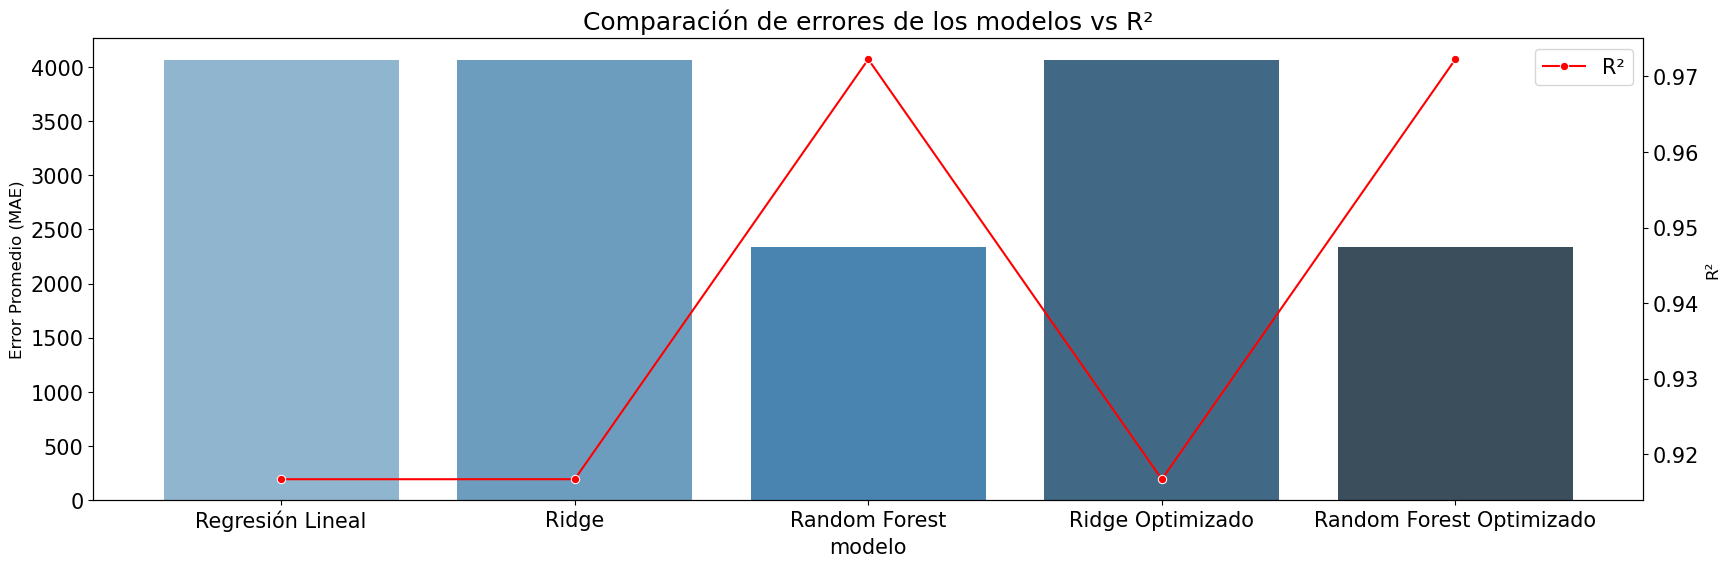

In [45]:
# Grafico los errores de los modelos.
fig, ax1 = plt.subplots(figsize = (20, 6))
sns.barplot(x = 'modelo', y = 'MAE', data = metricas_df, ax = ax1, hue = 'modelo', palette = 'Blues_d', legend = False)
ax1.set_ylabel('Error Promedio (MAE)', fontsize = 12)

# Creo un segundo eje para el R2.
ax2 = ax1.twinx()
sns.lineplot(x = 'modelo', y = 'R2', data = metricas_df, marker = 'o', color = 'red', ax = ax2, label = 'R²')
ax2.set_ylabel('R²', fontsize = 12)
ax2.legend(loc='upper right')

plt.title('Comparación de errores de los modelos vs R²')
plt.show()

En la gráfica, claramente se aprecia la diferencia entre Random Forest y los demás modelos. Por lejos, Random Forest es el modelo más robusto y que mejor predice el precio de boletos de avión de nuestros datos.

La diferencia entre usar una regresión lineal o el método Ridge es casi nula en términos de error promedio MAE.

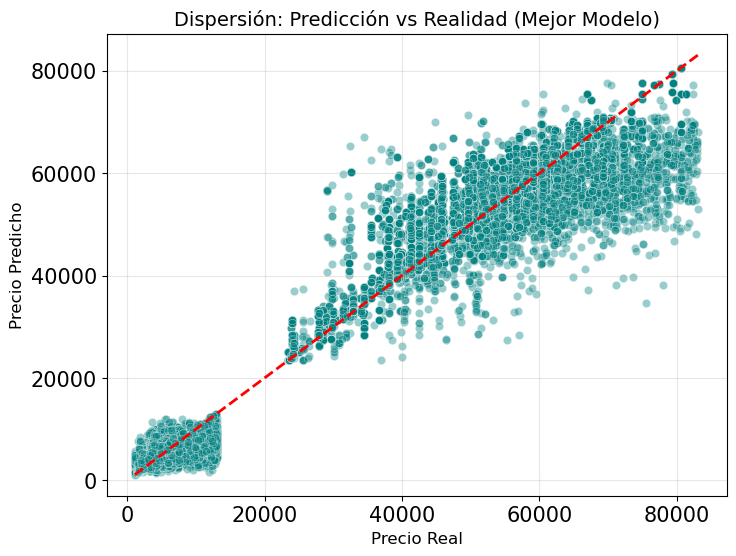

In [46]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_opt, alpha=0.4, color='teal')

# Línea de referencia (lo que sería una predicción perfecta)
linea_perfecta = [y_test.min(), y_test.max()]
plt.plot(linea_perfecta, linea_perfecta, color='red', linestyle='--', lw=2)

plt.xlabel('Precio Real', fontsize=12)
plt.ylabel('Precio Predicho', fontsize=12)
plt.title('Dispersión: Predicción vs Realidad (Mejor Modelo)', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

Esta gráfica nos muestra lo sólido del modelo Random Forest, ya que Los puntos se agrupan muy bien alrededor de la línea roja.

Además, se puede apreciar que existen dos grupos claramente diferenciados, la clase económica y los de business. Según la gráfica, el modelo es ligeramente mejor al predecir los precios más bajos que aquellos con valores más grandes.

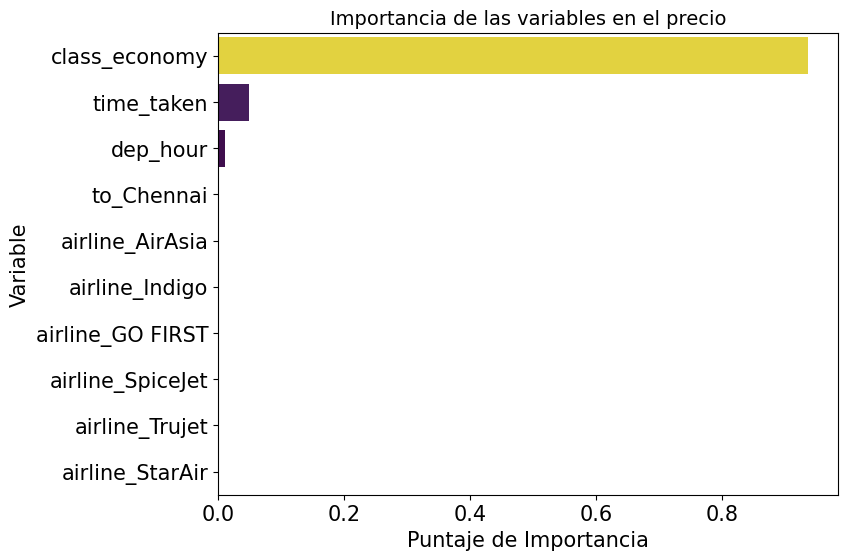

In [47]:
# Para el modelo de Random Forest, muestro la importancia que asignó a las variables utilizadas.
importancias = grid_search.best_estimator_.feature_importances_
df_imp = pd.DataFrame({'Variable': selected_features, 'Importancia': importancias})
df_imp = df_imp.sort_values(by = 'Importancia', ascending = False)

plt.figure(figsize = (8, 6))
sns.barplot(x = 'Importancia', y = 'Variable', data = df_imp, palette = 'viridis', hue = 'Importancia', legend = False)
plt.title('Importancia de las variables en el precio', fontsize = 14)
plt.xlabel('Puntaje de Importancia')
plt.show()

* Según lo anterior, para el modelo de Random Forest, la variable que más importancia le da es saber la clase a la que pertenece: si es económica o business.
* Para el modelo, la aerolínea y la ciudad de salida y destino no ayudan significativamente a predecir el precio de los boletos. En cambio, la duración de vuelo y la hora de salida sí le asigna cierta importancia.

**Conclusión:** 

* El uso de modelos predictivos de Machine Learning fue todo un éxito. Ya sólamente utilizando una regresión lineal sobre los datos se obtiene un R² superior a 0.9, bastante aceptable, aunque los errores MAE y RMSE son algo abultados.
* Debido a que el modelo Ridge se utiliza para tratar la multicolinealidad, el hecho que no exista diferencia significativa con la regresión lineal, sugiere que el Forward Selection hizo un gran trabajo al seleccionar las columnas más relevantes.
* El modelo Random Forest fue todo un éxito para predecir los precios de boletos de avión a partir de las variables seleccionadas, por lo que tiene un potencial real de ser aplicado.
* Saber que para Random Forest, sólo 3 variables fueron suficientes o de gran importancia para su predicción es de gran ayuda para no gastar recursos y tiempo considerando las otras variables de los datos.
* Además, RF hizo un gran trabajo al segmentar los precios e identificar los dos grupos existentes.

**Futuro proyecto**

* Dada los buenos resultados, se podría implementar el modelo al mundo real utilizando alguna API para obtener los datos de vuelos de aerolíneas en tiempo real.
* La creación de una página web para que el usuario pueda elegir una aerolínea, fecha de salidas, etc, y que pueda obtener un precio estimado de cuánto le costaría una boleto de avión.
* Los datos de los archivos que se usó no contiene información sobre la cantidad de pasajeros o el equipaje que lleva el usuario. Por lo que la obtención de esta información sería crucial y muy importante para la tener una predicción más completa de precios.
